# MNIST Dataset Exploration

## Objective

In this notebook, we will explore the MNIST handwritten digit dataset before building our neural network.

We will investigate:

- the structure and size of the dataset
- the shape and type of the input data
- the labels and their distribution
- pixel value ranges
- example images

The goal is to understand the data before making decisions about our model architecture and training process.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

PyTorch version: 2.13.0+cpu
Torchvision version: 0.28.0+cpu
NumPy version: 2.5.2
Pandas version: 3.0.5


## Loading MNIST

MNIST is a dataset of handwritten digits from 0 to 9. Each example is a grayscale image with dimensions of 28 x 28 pixels

In [3]:
train_dataset = torchvision.datasets.MNIST(
    root = "../data/raw",
    train = True,
    download = True,
    transform = transforms.ToTensor()
)

test_dataset = torchvision.datasets.MNIST(
    root = "../data/raw",
    train = False,
    download = True,
    transform = transforms.ToTensor()
)

## Dataset Structure

In [4]:
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

Train examples: 60000
Test examples: 10000


In [5]:
image, label = train_dataset[0]

print("Image type: ", type(image))
print("Image shape: ", image.shape)
print("Image dtype: ", image.dtype)
print("Label: ", label)

Image type:  <class 'torch.Tensor'>
Image shape:  torch.Size([1, 28, 28])
Image dtype:  torch.float32
Label:  5


In [6]:
print("Minimum pixel value: ", image.min().item())
print("Maximum pixel value: ", image.max().item())
print("Mean pixel value: ", image.mean().item())

Minimum pixel value:  0.0
Maximum pixel value:  1.0
Mean pixel value:  0.1376800686120987


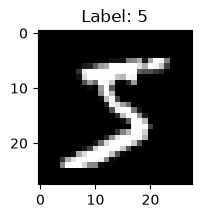

In [7]:
plt.figure(figsize=(2, 2))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

The MNIST samples are represented as PyTorch tensors with shape `(1, 28, 28)`, corresponding to one grayscale channel and 28 by 28 pixels.

After applying `ToTensor()`, pixel values are represented as floats in the range `0-1`

The label represents the digit contained in the image.

In [8]:
train_labels = train_dataset.targets

print("Train labels shape:", train_labels.shape)
print("Unique labels:", torch.unique(train_labels))

Train labels shape: torch.Size([60000])
Unique labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


Text(0.5, 1.0, 'Distribution of digits in the training set')

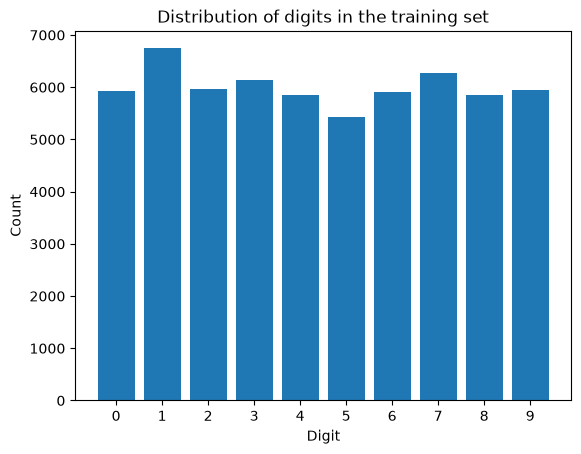

In [9]:
label_counts = torch.bincount(train_labels)

plt.bar(range(10), label_counts.numpy())
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Distribution of digits in the training set")

The class frequencies are relatively similar

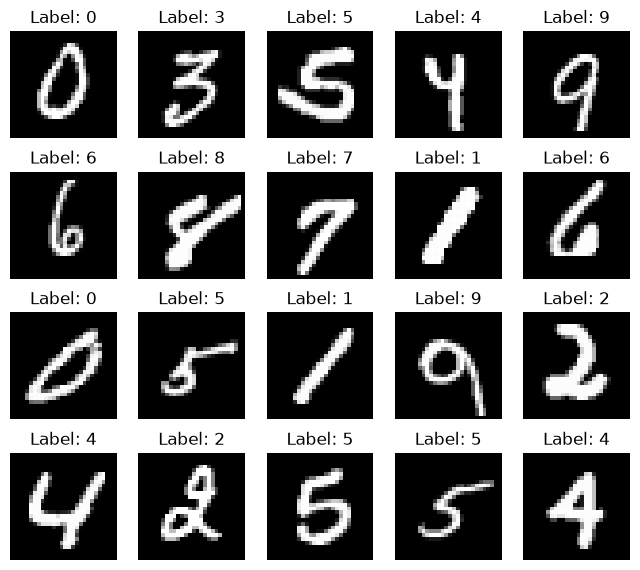

In [10]:
fig, axes = plt.subplots(4, 5, figsize=(8, 7))

for ax in axes.flat:
    index = np.random.randint(0, len(train_dataset))
    image, label = train_dataset[index]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.show()

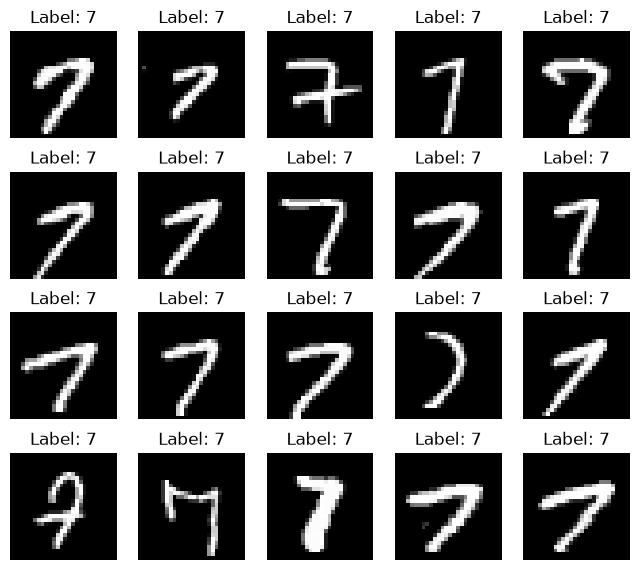

In [11]:
digit_to_inspect = 7

indices_of_digit = torch.where(train_labels == digit_to_inspect)[0]

fig, axes = plt.subplots(4, 5, figsize=(8, 7))

for ax, index in zip(axes.flat, indices_of_digit[:20]):
    image, label = train_dataset[index]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.show()

This shows that the same label can have significantly different visual appearances. This gives us the intuition for why we will want a CNN to solve this.

MNIST images are grayscale, so each pixel represents the intensity of the image at that location.

After `ToTensor()`, these values lie between 0 and 1.

We will examine their distribution to understand how much of the image is typically background versus ink.

In [12]:
all_pixels = torch.stack([image for image, _ in train_dataset])

print("Shape: ", all_pixels.shape)
print("Min: ", all_pixels.min().item())
print("Max: ", all_pixels.max().item())
print("Mean: ", all_pixels.mean().item())
print("Std: ", all_pixels.std().item())

Shape:  torch.Size([60000, 1, 28, 28])
Min:  0.0
Max:  1.0
Mean:  0.13066047430038452
Std:  0.30810782313346863


Text(0.5, 1.0, 'Histogram of pixel intensities in the training set')

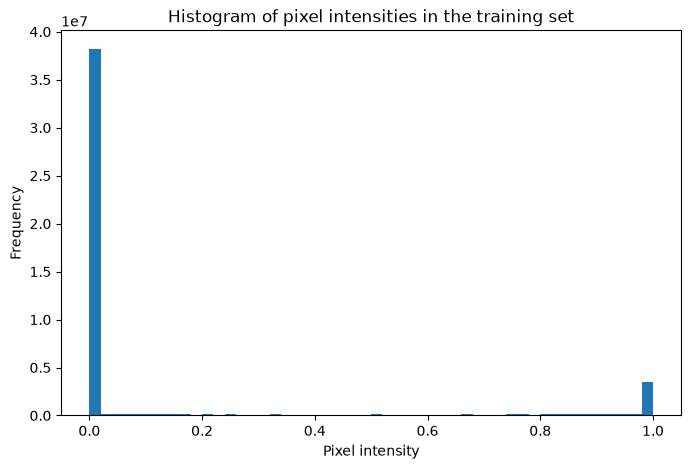

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(all_pixels.numpy().flatten(), bins=50)
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.title("Histogram of pixel intensities in the training set")

The pixel intensity distribution is heavily concentrated near zero.

This is expected because most pixels in a 28 × 28 MNIST image represent the background rather than the handwritten digit itself.

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

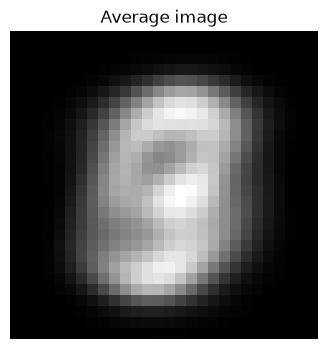

In [14]:
mean_image = all_pixels.mean(dim=0).squeeze()

plt.figure(figsize=(4, 4))
plt.imshow(mean_image, cmap="gray")
plt.title("Average image")
plt.axis("off")

The average image reveals the regions of the 28 × 28 image where handwritten strokes are most frequently present.

Although the average image does not correspond to a specific digit, it provides a useful overview of the spatial structure of the dataset.

This reinforces that the spatial arrangement of pixels is important, which is one reason convolutional neural networks are well suited to this task.

We can make this more informative by calculating a separate average image for each digit. This allows us to see the characteristic spatial structure of each class and compare how visually distinct the digits are.

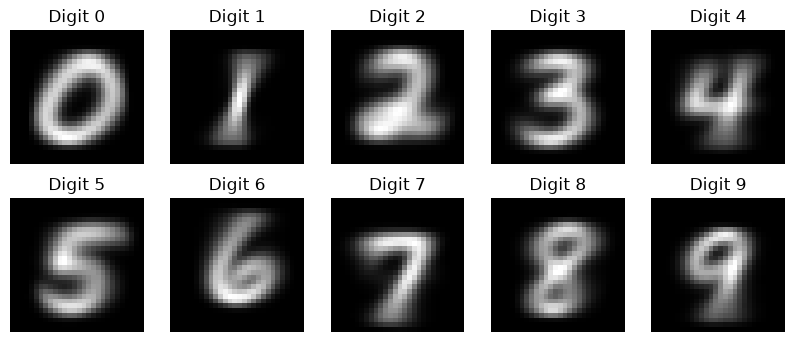

In [15]:
mean_images = []

for digit in range(10):
    digit_images = all_pixels[train_labels == digit]
    mean_image = digit_images.mean(dim=0).squeeze()
    mean_images.append(mean_image)

fig, axes = plt.subplots(2, 5, figsize = (10, 4))

for digits, ax in enumerate(axes.flat):
    ax.imshow(mean_images[digits], cmap="gray")
    ax.set_title(f"Digit {digits}")
    ax.axis("off")

Let's verify that the test data has the same basic structure and class distribution as the training set.

In [16]:
print("Training:")
print("Samples:", len(train_dataset))
print("Shape:", train_dataset[0][0].shape)

print("Test:")
print("Samples:", len(test_dataset))
print("Shape:", test_dataset[0][0].shape)

Training:
Samples: 60000
Shape: torch.Size([1, 28, 28])
Test:
Samples: 10000
Shape: torch.Size([1, 28, 28])


In [17]:
test_label_counts = torch.bincount(test_dataset.targets)

distribution = pd.DataFrame({
    "Train": label_counts.numpy(),
    "Test": test_label_counts.numpy()
})

distribution.index.name = "Digit"

distribution

,Train,Test
Digit,,
0,5923,980
1,6742,1135
2,5958,1032
3,6131,1010
4,5842,982
5,5421,892
6,5918,958
7,6265,1028
8,5851,974


# EDA Summary

## Dataset

- 60,000 training images
- 10,000 test images
- 10 classes representing digits 0–9
- Images are 28 × 28 pixels
- Images contain a single grayscale channel

## Pixel Representation

- Original MNIST pixels use values from 0 to 255.
- `ToTensor()` converts them to floating-point values in the range `[0, 1]`.
- Most pixels are close to zero because most of each image is background.

## Class Distribution

The ten classes are relatively evenly represented. There is some variation in class frequency, but no severe class imbalance was observed.

## Visual Variation

The dataset contains significant variation in handwriting style. Examples belonging to the same class can have noticeably different appearances.

Some classes also exhibit visually similar structures, making certain classification errors more plausible than others.

## Train/Test Split

The training and test sets contain the same classes and have broadly similar class distributions, while containing separate examples.

## Model Implications

Based on the EDA, the problem is well suited to image classification using a convolutional neural network.

The spatial structure of the 28 × 28 images is meaningful, and the variation in handwriting suggests that the model must learn robust visual features rather than memorize individual pixel patterns.

## Next Step

Before implementing a CNN, we will establish a simple baseline model.

This will give us a reference point against which we can measure the benefit of introducing convolutional layers.